# Pre-MS stars

This notebook can be used to have a quicklook at the that product for the simulations.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# PlatoSim libraries
import platosim.plot      as pt
import platosim.mocka     as mk
import platosim.utilities as ut
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [3]:
path = Path(os.getenv('PLATO_WORKDIR')) / 'pre-ms'
idir = path / 'input'
sdir = path / 'simulations' 

---
## 1. Stellar catalogue
---

In [4]:
# Load PLATO-CS catalogue
df = pd.read_feather(path / '../PlatoCS/input/starcat_PlatoCS_NCAM_LOPS2.ftr')

In [5]:
# Load Pre-MS catalogue
dt = pd.read_csv(path / 'input/plato_sample.txt', sep=' ', comment='#',
                 names=['ID', 'gaiaDR3', 'Pmag', 'Gmag', 'ra', 'dec'])
dt.head()

,ID,gaiaDR3,Pmag,Gmag,ra,dec
0,1,2885659097345755648,14.841428,15.018138,94.514026,-34.544374
1,2,2886290079581074432,15.142609,15.319207,93.342170,-35.022312
2,3,2890046080021476352,14.823780,14.999045,91.413240,-32.674862
3,4,2895540751943528960,16.155236,16.329124,97.784416,-29.021455
4,5,2895546146422412800,15.847063,16.032137,97.996331,-28.911655


<IPython.core.display.Javascript object>


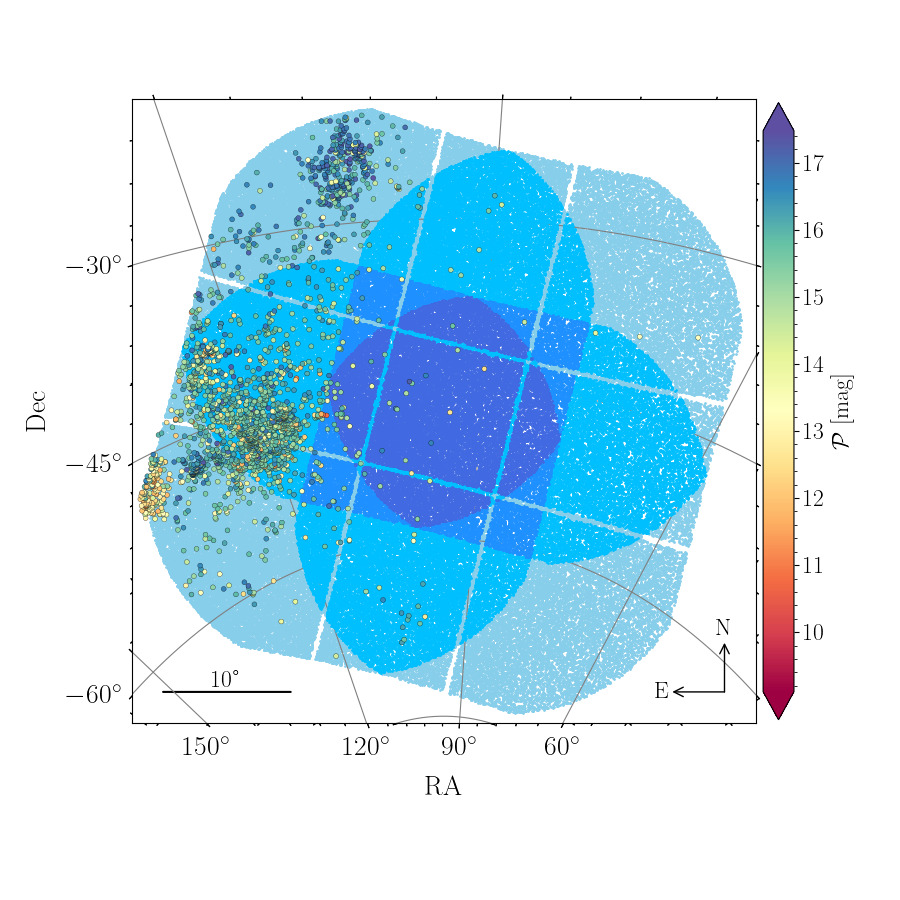

In [65]:
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=dt.ra, decStars=dt.dec, c=dt.Pmag, s=50, lw=0.2, 
                          ncamStars=True, clabel=r'$\mathcal{P}$ [mag]', system='icrs',
                          figsize=(9,9))
# fig.savefig(f'{pdir}/starcat_sky_EBs.png', bbox_inches='tight', dpi=200)

In [19]:
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / 'starcat_PreMS_targets.ftr')

In [20]:
# Create contaminant catalogue
dc = ut.getContaminants(dt, df, column='gaiaDR3')
dc.to_feather(idir / 'starcat_PreMS_contaminants.ftr')

100%|██████████████████████████████████████████████████| 2452/2452 [04:30<00:00,


---
## 2. Post-processing
---

We ran a few test simulations saving the default photometry to the HDF5 file:
```
platonium 1 2 1 1 --project pre-ms --varsource_test.txt 
```

In [88]:
# Load file to test detrending with
filename = f"{sdir}/test/hdf5/000000001/000000001_Ncam2.1_Q1.hdf5"

# Load a single mission quarter light curve
lc = LightCurve(filename, mode="single")
dt = lc.star()
dt

,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,2.885659e+18,94.514026,-34.544374,14.841428,2,1,1,4,858.602157,2972.11676,7.70238,28.981898,16.754839,3,0.006829


<IPython.core.display.Javascript object>


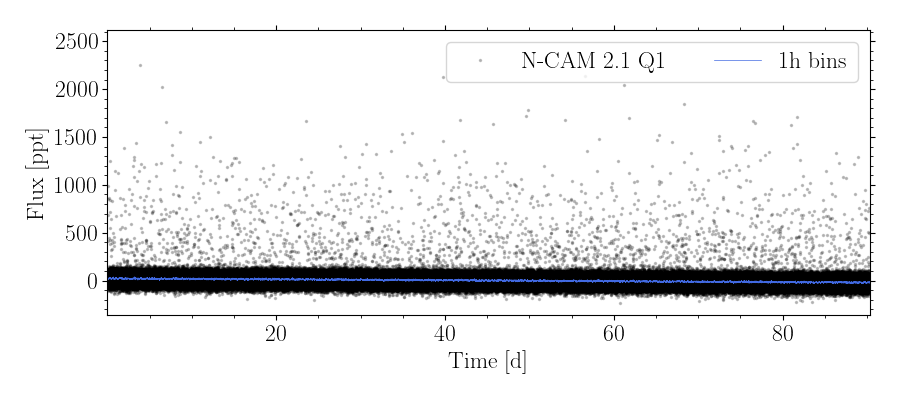

In [89]:
# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=False, figsize=(9,4));

### 2.1. Test detrending

<IPython.core.display.Javascript object>


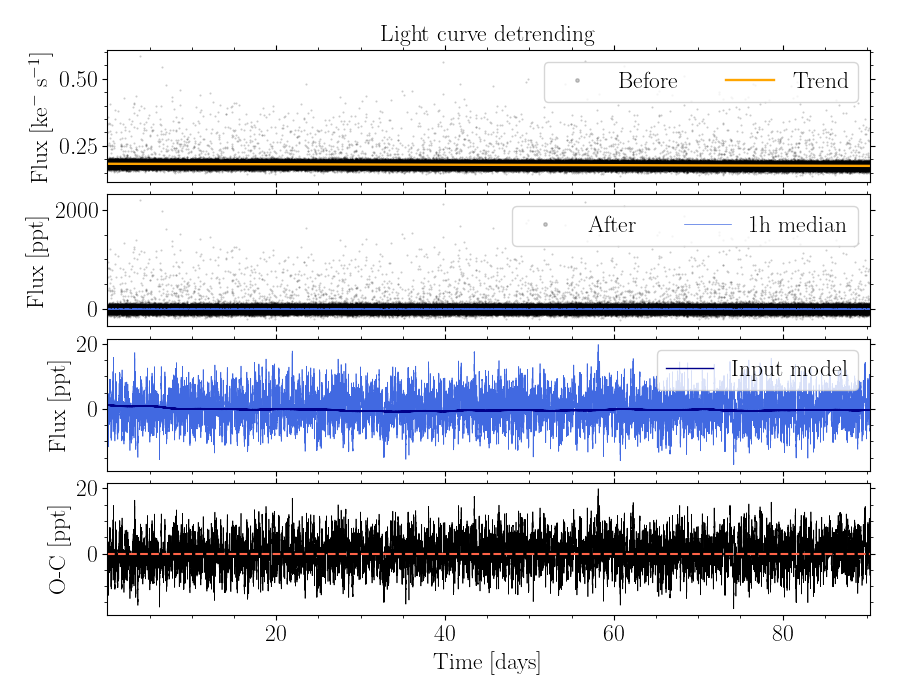

In [90]:
# Generate plot to save
df = lc.detrend(model='poly', replace=True, plot=True)

### 2.2. Test outlier rejection

<IPython.core.display.Javascript object>


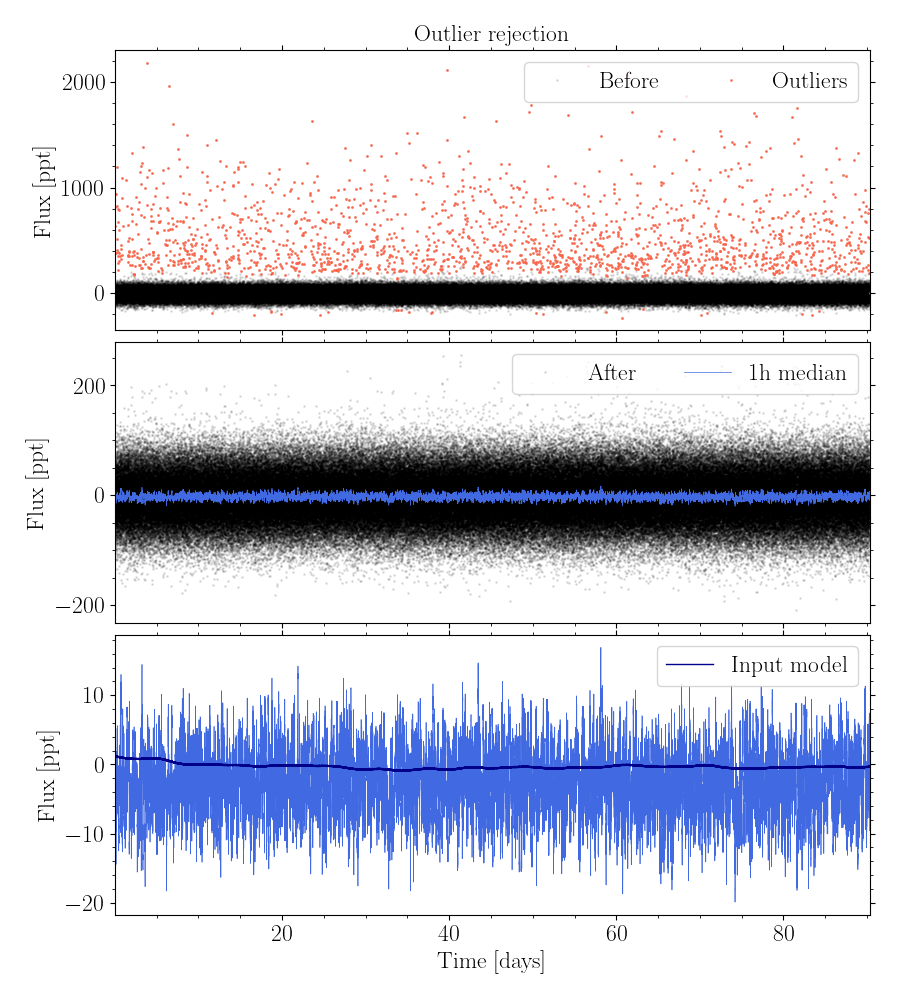

In [94]:
# Remove outliers (due to photon noise and cosmic ray hits)
df = lc.clip(model='wotan', sigma_lower=3, sigma_upper=3, flux_unit='ppt', plot=True)

---
## 3. Analysis of simulations
---

In [98]:
# Initialise light curve object
star = '000000001'
fdir = sdir / 'test/ftr' / star
lcs = LightCurve(fdir, mode="multi")

In [99]:
# Create table with simulation statistics
df = lcs.stat_sim_table(ofile=fdir / f'lc_{star}.tab', clean=True)
df.head()

[Warning]: Remove your "ofile" to use "clean" (if ".table" files still exists)


,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,2.885659e+18,94.514026,-34.544374,14.841428,1,1,2,3,858.281052,2971.845771,7.702682,16.749059,-28.986776,3,0.002125
1,1,2.885659e+18,94.514026,-34.544374,14.841428,1,1,3,1,1572.031236,2376.796389,11.312664,-29.596562,39.697665,3,0.010706
2,1,2.885659e+18,94.514026,-34.544374,14.841428,1,1,6,3,858.498991,2971.966790,7.702700,16.752982,-28.984598,3,0.003174
3,1,2.885659e+18,94.514026,-34.544374,14.841428,1,1,7,1,1571.971656,2376.549462,11.313314,-29.595490,39.702110,3,0.006418
4,1,2.885659e+18,94.514026,-34.544374,14.841428,1,2,2,3,868.824595,2984.312832,7.680356,16.938843,-28.762369,3,0.011005


<IPython.core.display.Javascript object>


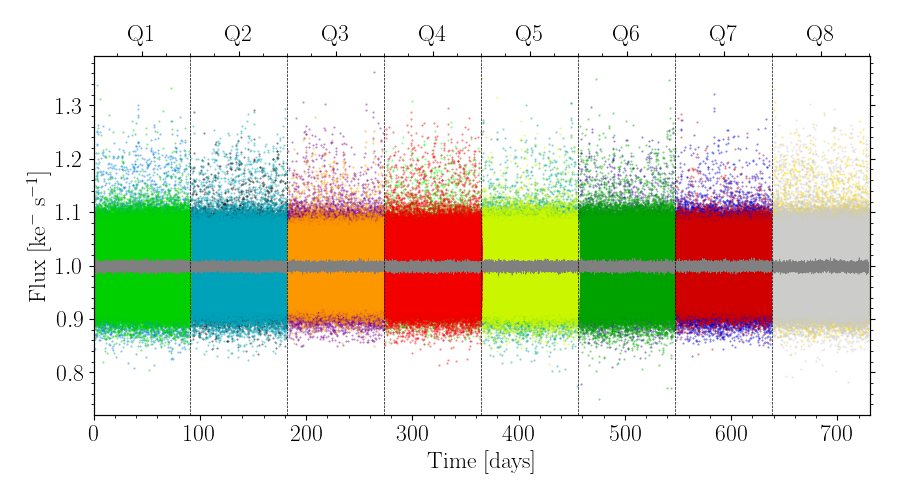

In [124]:
# Show all light curves
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=1, quarter=False, 
                         flux_median=144, alpha=0.5, figsize=(9,5))

Processing star ID 000000001
-------------------------------------------------------
Merging 96 light curves


100%|██████████████████████████████████████████████████| 96/96 [00:08<00:00, 11.19it/s]                                                                       


Sorting data after timings
Averaging data from same camera group
Corrrecting flux offset of 1.0 ppm
Calculating flux errors


<IPython.core.display.Javascript object>


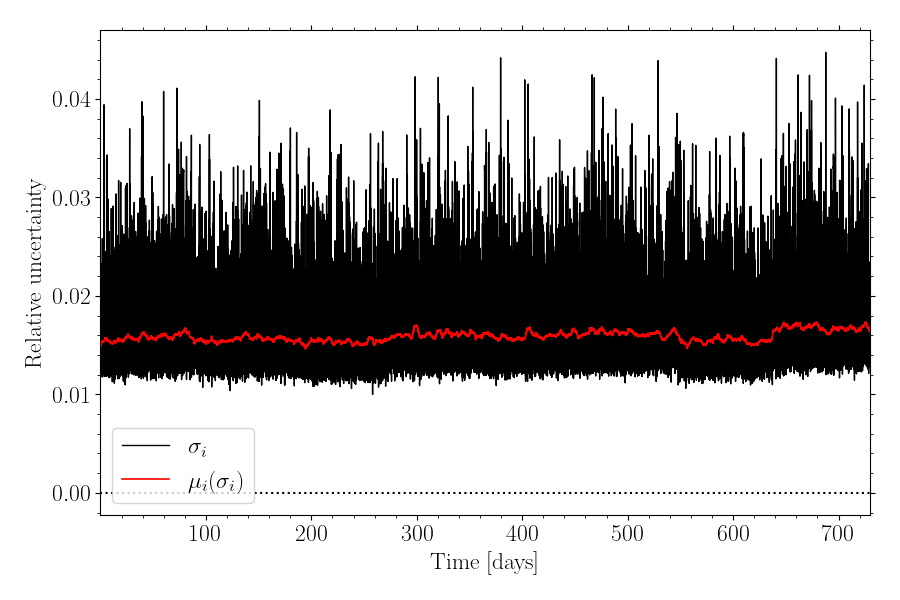

Saving light curve
-------------------------------------------------------


In [73]:
# Post-processing into final light curve
lc = lcs.merge(suffix='ftr',
               flux_error=True,
               flux_offset=True,
               flux_group_mean=True,
               clip_sigma=None,
               ofile= fdir / f'lc_{star}.ftr'
              )

<IPython.core.display.Javascript object>


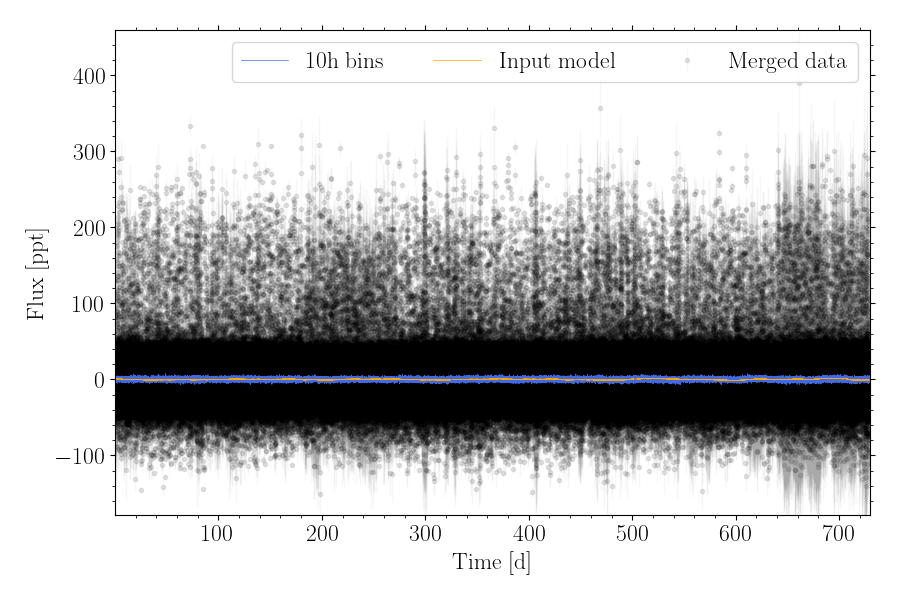

In [75]:
# Show result
lc.plot(input_model=True, flux_unit='ppt', flux_error=True, median_filter=10, alpha=0.1, figsize=(9,6));

---
## Final data products
---

<IPython.core.display.Javascript object>


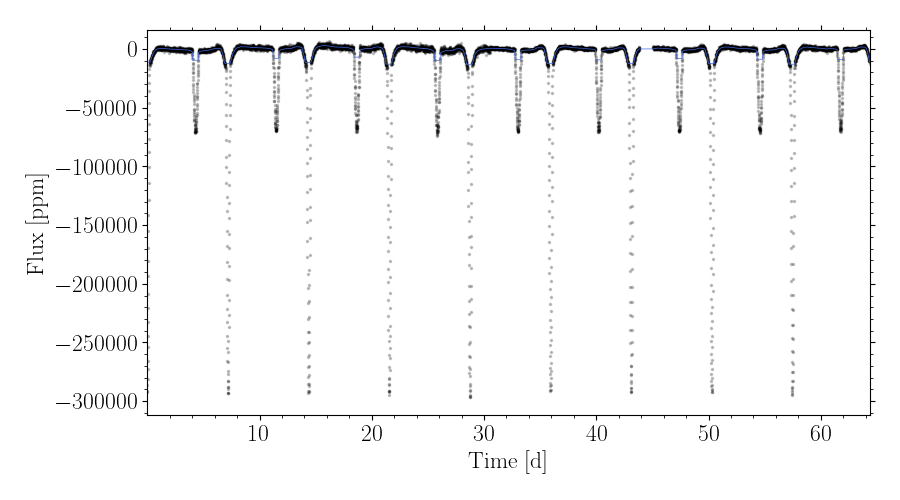

In [8]:
path = '/lhome/nicholas/software/workdir/cs-binary/finals'
star = 'mag085/lc_000000001.ftr'

# In multi mode we parse the entire directory of files
lc = LightCurve(f'{path}/{star}', mode="final")

# Introduce gaps from file
inputFileGap = '/lhome/nicholas/software/workdir/mocka/input/instrumentGAP.tab'
lc.gaps(inputFileGap, replace=True, plot=False);

# Show a quarter light curve
lc.plot(flux_unit='ppm', median_filter=1, input_model=True, legend=False, figsize=(9,5));

<IPython.core.display.Javascript object>


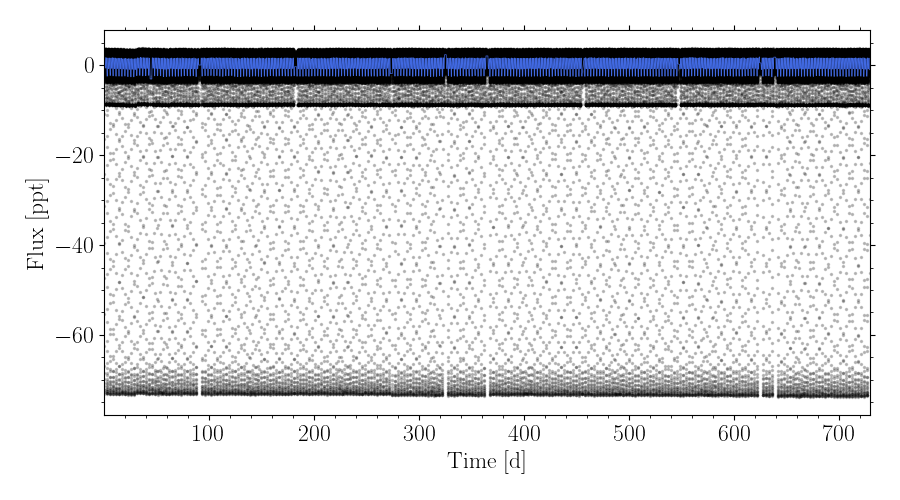

In [183]:
path = '/lhome/nicholas/software/workdir/cs-binary/finals'
star = 'mag085/lc_000000090.ftr'

# In multi mode we parse the entire directory of files
lc = LightCurve(f'{path}/{star}', mode="final")

# Introduce gaps from file
inputFileGap = '/lhome/nicholas/software/workdir/mocka/input/instrumentGAP.tab'
lc.gaps(inputFileGap, replace=True, plot=False);

# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=False, legend=False, figsize=(9,5));